# TabDDPM: Hospital Readmission Prediction
## Stage 1 — Data Preprocessing

**Goal:** Convert the raw `diabetic_data.csv` into clean, fully numeric, scaled, and split datasets ready for baseline modelling, synthetic data generation (SMOTE / CTGAN / TabDDPM), and evaluation.

**Output of this stage:**
- `data/processed/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`
- `models/scaler.pkl`, `models/label_encoders.pkl`

---
## 1. Setup & Imports

All libraries needed for this stage. `warnings` is silenced to keep output clean. A global `RANDOM_STATE` pins all stochastic operations for reproducibility.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)

print('All imports successful.')

All imports successful.


---
## 2. Load Raw Data

Read the CSV, confirm shape (expect ~101 766 rows × 50 columns), and take a first look at the raw values — including the `?` placeholders used for missing data.

In [2]:
DATA_PATH = '/content/diabetic_data.csv'
df = pd.read_csv(DATA_PATH)

print(f'Shape of the dataset: {df.shape}')
df.head()

Shape of the dataset: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


---
## 3. Initial Data Exploration

Before touching anything we need to understand:
1. What data types are present
2. Which columns have `?` (the dataset's missing-value sentinel)
3. How the target variable (`readmitted`) is distributed — this reveals the class imbalance we need to fix

----- Column dtype counts -----
object    37
int64     13
Name: count, dtype: int64

----- Columns with missing values -----
                   ? count    pct
weight               98569  96.9%
medical_specialty    49949  49.1%
payer_code           40256  39.6%
race                  2273   2.2%
diag_3                1423   1.4%
diag_2                 358   0.4%
diag_1                  21   0.0%

----- Target Variable (readmitted) -----
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


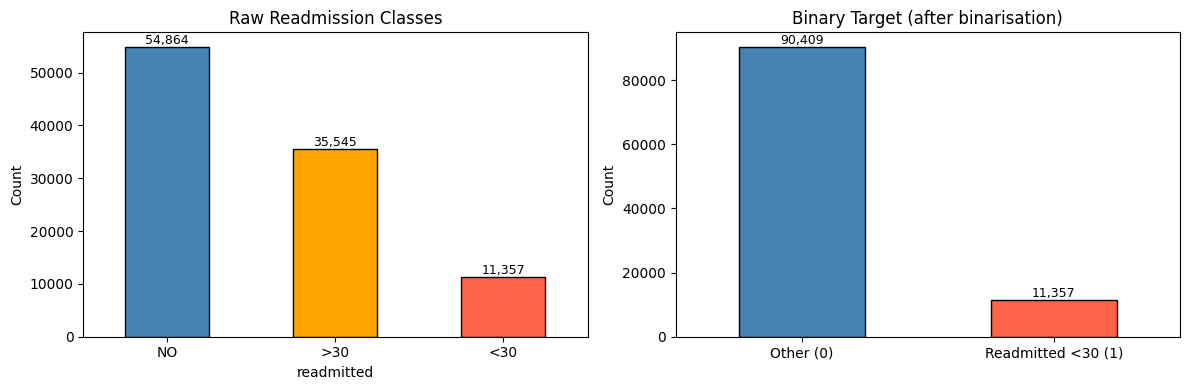

In [3]:
# Data types of the columns
print('----- Column dtype counts -----')
print(f'{df.dtypes.value_counts()}\n')

# Columns with missing values (Represented as '?' in the raw dataset)
missing = (df == '?').sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('----- Columns with missing values -----')
print(missing.to_frame('? count').assign(
    pct=lambda x: (x['? count'] / len(df) * 100).round(1).astype(str) + '%'
))
print()

# Target distribution
print('----- Target Variable (readmitted) -----')
print(df['readmitted'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df['readmitted'].value_counts()
vc.plot(kind='bar', ax=axes[0], color=['steelblue', 'orange', 'tomato'], edgecolor='black')
axes[0].set_title('Raw Readmission Classes')
axes[0].set_xlabel('readmitted')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

binary_vc = (df['readmitted'] == '<30').value_counts()
binary_vc.index = ['Other (0)', 'Readmitted <30 (1)']
binary_vc.plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_title('Binary Target (after binarisation)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. Drop Irrelevant & Unrecoverable Columns

Six columns are removed before any modelling:

| Column | Reason |
|---|---|
| `encounter_id` | Row identifier — no signal |
| `patient_nbr` | Patient identifier — no signal |
| `weight` | ~97% missing — unrecoverable |
| `payer_code` | ~40% missing, not clinically required |
| `medical_specialty` | ~49% missing, very high cardinality |
| `examide`, `citoglipton` | Near-zero variance — almost always `'No'` |

In [4]:
COLS_TO_DROP = [
    'encounter_id', 'patient_nbr',   # identifiers
    'weight',                          # 97% missing
    'payer_code',                      # 40% missing
    'medical_specialty',               # 49% missing, high cardinality
    'examide', 'citoglipton',         # near-zero variance
]

df.drop(columns=COLS_TO_DROP, inplace=True)
print(f'Shape after dropping {len(COLS_TO_DROP)} columns: {df.shape}')

Shape after dropping 7 columns: (101766, 43)


---
## 5. Remove Expired & Hospice Patients

Patients who died or were discharged to hospice **cannot be readmitted**. Keeping them would introduce impossible positive labels and confuse the classifier. We identify them via `discharge_disposition_id`:

| ID | Meaning |
|---|---|
| 11 | Expired |
| 13 | Hospice / medical facility |
| 14 | Hospice / home |
| 19 | Expired at home |
| 20 | Expired in another facility |
| 21 | Expired — place unknown |

In [5]:
EXPIRED_IDS = {11, 13, 14, 19, 20, 21}
before = len(df)
df = df[~df['discharge_disposition_id'].isin(EXPIRED_IDS)].copy()
print(f'Removed {before - len(df):,} expired / hospice records.')
print(f'Shape after removal: {df.shape}')

Removed 2,423 expired / hospice records.
Shape after removal: (99343, 43)


---
## 6. Handle Missing Values

All `?` are now converted to `NaN`. Then:
- **`race`** (~2% missing) → imputed with the column mode (most common race)
- **`gender`** → the handful of `'Unknown/Invalid'` rows are dropped (not imputable)
- **`diag_1/2/3`** → NaN handled inside the ICD-9 mapping function in the next step

In [6]:
# Replace sentinel '?' with NaN
df.replace('?', np.nan, inplace=True)

nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0].sort_values(ascending=False)
print('=== NaN counts after ? replacement ===')
print(nan_counts.to_frame('NaN count').assign(
    pct=lambda x: (x['NaN count'] / len(df) * 100).round(1).astype(str) + '%'
))

# Impute race with mode
df['race'].fillna(df['race'].mode()[0], inplace=True)

# Drop the few Unknown/Invalid gender rows
before = len(df)
df = df[df['gender'] != 'Unknown/Invalid'].copy()
print(f'\nDropped {before - len(df)} rows with Unknown/Invalid gender.')

remaining_na = df.isna().sum()
remaining_na = remaining_na[remaining_na > 0]
if len(remaining_na) == 0:
    print('No remaining NaN values outside diag columns (handled in feature engineering).')
else:
    print('\nRemaining NaN:')
    print(remaining_na)

print(f'\nShape: {df.shape}')

=== NaN counts after ? replacement ===
               NaN count    pct
max_glu_serum      94191  94.8%
A1Cresult          82509  83.1%
race                2234   2.2%
diag_3              1419   1.4%
diag_2               356   0.4%
diag_1                20   0.0%

Dropped 3 rows with Unknown/Invalid gender.

Remaining NaN:
diag_1              20
diag_2             356
diag_3            1419
max_glu_serum    94188
A1Cresult        82506
dtype: int64

Shape: (99340, 43)


---
## 7. Encode Target Variable

We convert the 3-class `readmitted` column into a **binary target**:

| Original | Binary | Meaning |
|---|---|---|
| `<30` | **1** | Readmitted within 30 days — the rare, high-risk class |
| `NO` | **0** | Not readmitted |
| `>30` | **0** | Readmitted after 30 days (not the clinically urgent case) |

This matches the proposal's focus: detect the ~11% minority class.

In [7]:
df['target'] = (df['readmitted'] == '<30').astype(int)
df.drop(columns=['readmitted'], inplace=True)

vc = df['target'].value_counts()
print('=== Binary Target Distribution ===')
print(f"0 (not readmitted <30): {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)")
print(f"1 (readmitted  <30):    {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)")
print(f'\nImbalance ratio: {vc[0]/vc[1]:.1f}:1')

=== Binary Target Distribution ===
0 (not readmitted <30): 88,026  (88.6%)
1 (readmitted  <30):    11,314  (11.4%)

Imbalance ratio: 7.8:1


---
## 8. Feature Engineering

Four transformations to make raw features usable:

1. **`age`** — bracket strings like `[50-60)` → numeric midpoint `55`
2. **`diag_1/2/3`** — ICD-9 codes grouped into 8 clinically meaningful disease categories (Circulatory, Respiratory, Digestive, Diabetes, Injury, Musculoskeletal, Genitourinary, Neoplasms, Other)
3. **Medication columns (21)** — ordinal encoding: `No=0, Steady=1, Up=2, Down=3`
4. **Binary/ordinal columns** — `change`, `diabetesMed`, `gender`, `A1Cresult`, `max_glu_serum`

In [8]:
# ── 1. Age brackets → numeric midpoint ───────────────────────────────────────
age_map = {
    '[0-10)': 5,  '[10-20)': 15, '[20-30)': 25, '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55, '[60-70)': 65, '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age'] = df['age'].map(age_map)
print('age midpoints applied:', sorted(df['age'].unique()))

# ── 2. ICD-9 diagnosis codes → disease category ──────────────────────────────
def icd9_to_category(code):
    """Map an ICD-9 code string to a broad disease category."""
    if pd.isna(code):
        return 'Other'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        num = float(code)
        if 390 <= num <= 459 or num == 785:  return 'Circulatory'
        if 460 <= num <= 519 or num == 786:  return 'Respiratory'
        if 520 <= num <= 579 or num == 787:  return 'Digestive'
        if 250 <= num < 251:                  return 'Diabetes'
        if 800 <= num <= 999:                 return 'Injury'
        if 710 <= num <= 739:                 return 'Musculoskeletal'
        if 580 <= num <= 629 or num == 788:  return 'Genitourinary'
        if 140 <= num <= 239:                 return 'Neoplasms'
        return 'Other'
    except ValueError:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].apply(icd9_to_category)

print('\ndiag_1 category counts:')
print(df['diag_1'].value_counts())

# ── 3. Medication columns → ordinal 0-3 ──────────────────────────────────────
MED_COLS = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]
med_map = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}
df[MED_COLS] = df[MED_COLS].replace(med_map)
print(f'\n{len(MED_COLS)} medication columns encoded (No=0, Steady=1, Up=2, Down=3)')

# ── 4. Binary / ordinal categoricals ─────────────────────────────────────────
df['change']      = (df['change'] == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)
df['gender']      = (df['gender'] == 'Male').astype(int)

# Convert NaN from "?" replacement into explicit "None" buckets before mapping.
# This preserves missing-lab semantics and avoids leaving these columns as NaN floats.
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult']     = df['A1Cresult'].fillna('None')

glu_map = {'None': 0, 'Norm': 1, '>200': 2, '>300': 3}
a1c_map = {'None': 0, 'Norm': 1, '>7': 2, '>8': 3}
df['max_glu_serum'] = df['max_glu_serum'].map(glu_map)
df['A1Cresult']     = df['A1Cresult'].map(a1c_map)

print('Binary/ordinal encodings complete.')
print(f'\nShape: {df.shape}')

age midpoints applied: [np.int64(5), np.int64(15), np.int64(25), np.int64(35), np.int64(45), np.int64(55), np.int64(65), np.int64(75), np.int64(85), np.int64(95)]

diag_1 category counts:
diag_1
Circulatory        29680
Other              17813
Respiratory        13934
Digestive           9333
Diabetes            8661
Injury              6851
Genitourinary       5002
Musculoskeletal     4935
Neoplasms           3131
Name: count, dtype: int64

21 medication columns encoded (No=0, Steady=1, Up=2, Down=3)
Binary/ordinal encodings complete.

Shape: (99340, 43)


---
## 9. Encode Remaining Categorical Columns

Four string columns remain after feature engineering: `race`, `diag_1`, `diag_2`, `diag_3`.

We use **`LabelEncoder`** (integer codes, not one-hot) because:
- TabDDPM needs integer-coded categoricals to apply multinomial diffusion
- SMOTE and XGBoost also handle label-encoded categoricals without issue

Encoders are saved to disk so the same mapping can be applied to any new/synthetic data.

In [9]:
CAT_COLS = ['race', 'diag_1', 'diag_2', 'diag_3']
label_encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'{col:8s}: {list(le.classes_)} → {list(range(len(le.classes_)))}')

print(f'\nAll columns are now numeric.')
print(df.dtypes.value_counts())
print(f'Shape: {df.shape}')

race    : ['AfricanAmerican', 'Asian', 'Caucasian', 'Hispanic', 'Other'] → [0, 1, 2, 3, 4]
diag_1  : ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory'] → [0, 1, 2, 3, 4, 5, 6, 7, 8]
diag_2  : ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory'] → [0, 1, 2, 3, 4, 5, 6, 7, 8]
diag_3  : ['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory'] → [0, 1, 2, 3, 4, 5, 6, 7, 8]

All columns are now numeric.
int64    43
Name: count, dtype: int64
Shape: (99340, 43)


---
## 10. Stratified Train-Test Split

Split **before** scaling so the scaler never sees test-set values. Using `stratify=y` preserves the ~11% minority-class ratio in both sets. The test set is held out entirely — it exists only for final evaluation.

In [10]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train : {X_train.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows')
print(f'Features: {X_train.shape[1]}')

for name, y_split in [('Train', y_train), ('Test', y_test)]:
    vc = y_split.value_counts().sort_index()
    print(f'\n{name} class distribution:')
    for cls, cnt in vc.items():
        print(f'  Class {cls}: {cnt:,}  ({cnt/len(y_split)*100:.1f}%)')

Train : 79,472 rows  |  Test : 19,868 rows
Features: 42

Train class distribution:
  Class 0: 70,421  (88.6%)
  Class 1: 9,051  (11.4%)

Test class distribution:
  Class 0: 17,605  (88.6%)
  Class 1: 2,263  (11.4%)


---
## 11. Scale Continuous Numeric Features

`StandardScaler` is **fit on `X_train` only**, then applied to both splits. This prevents test-set statistics from leaking into the scaler’s mean/std — fitting on the full dataset before splitting is data leakage that makes evaluation results optimistically biased.

In [11]:
NUMERIC_COLS = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses', 'age'
]

scaler = StandardScaler()
X_train[NUMERIC_COLS] = scaler.fit_transform(X_train[NUMERIC_COLS])  # fit + transform on train only
X_test[NUMERIC_COLS]  = scaler.transform(X_test[NUMERIC_COLS])       # transform only — no re-fitting

print('StandardScaler fit on X_train only, applied to both splits.')
print('\nX_train numeric stats (expect mean≈0, std≈1):')
print(X_train[NUMERIC_COLS].describe().T[['mean', 'std', 'min', 'max']].round(3))
print('\nX_test numeric stats (slight deviation from 0/1 is normal — no leakage):')
print(X_test[NUMERIC_COLS].describe().T[['mean', 'std', 'min', 'max']].round(3))

StandardScaler fit on X_train only, applied to both splits.

X_train numeric stats (expect mean≈0, std≈1):
                     mean   std    min    max
time_in_hospital    0.000 1.000 -1.138  3.237
num_lab_procedures -0.000 1.000 -2.138  4.385
num_procedures      0.000 1.000 -0.784  2.744
num_medications    -0.000 1.000 -1.849  7.768
number_outpatient  -0.000 1.000 -0.294 32.881
number_emergency   -0.000 1.000 -0.207 78.539
number_inpatient    0.000 1.000 -0.501 16.131
number_diagnoses    0.000 1.000 -3.298  4.428
age                -0.000 1.000 -3.808  1.834

X_test numeric stats (slight deviation from 0/1 is normal — no leakage):
                     mean   std    min    max
time_in_hospital   -0.004 0.995 -1.138  3.237
num_lab_procedures -0.013 0.997 -2.138  4.538
num_procedures      0.003 1.006 -0.784  2.744
num_medications    -0.009 0.990 -1.849  8.015
number_outpatient  -0.011 0.997 -0.294 31.302
number_emergency   -0.008 0.849 -0.207 43.310
number_inpatient   -0.005 0.991 -0.50

---
## 12. Save Processed Data & Preview

Processed splits are written to `data/processed/` so every subsequent stage (baseline, SMOTE, CTGAN, TabDDPM) loads from the same clean starting point without re-running this notebook.

Preprocessing artifacts (scaler, label encoders) are saved to `models/` so synthetic data and new inference data can be preprocessed identically.

In [12]:
PROCESSED_DIR = '../data/processed'
MODELS_DIR = '../models'
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Save splits
X_train.to_csv(f'{PROCESSED_DIR}/X_train.csv', index=False)
X_test.to_csv(f'{PROCESSED_DIR}/X_test.csv', index=False)
y_train.to_csv(f'{PROCESSED_DIR}/y_train.csv', index=False)
y_test.to_csv(f'{PROCESSED_DIR}/y_test.csv', index=False)

# Save preprocessing artifacts
joblib.dump(scaler, f'{MODELS_DIR}/scaler.pkl')
joblib.dump(label_encoders, f'{MODELS_DIR}/label_encoders.pkl')

print('Files saved:')
print(f'  {PROCESSED_DIR}/X_train.csv  — {X_train.shape}')
print(f'  {PROCESSED_DIR}/X_test.csv   — {X_test.shape}')
print(f'  {PROCESSED_DIR}/y_train.csv  — {y_train.shape}')
print(f'  {PROCESSED_DIR}/y_test.csv   — {y_test.shape}')
print(f'  {MODELS_DIR}/scaler.pkl')
print(f'  {MODELS_DIR}/label_encoders.pkl')

Files saved:
  ../data/processed/X_train.csv  — (79472, 42)
  ../data/processed/X_test.csv   — (19868, 42)
  ../data/processed/y_train.csv  — (79472,)
  ../data/processed/y_test.csv   — (19868,)
  ../models/scaler.pkl
  ../models/label_encoders.pkl


In [13]:
print('=== Cleaned Training Data — First 10 Rows ===')
display(X_train.head(10))

print(f'\n=== Feature Summary ({len(X_train.columns)} features) ===')
summary = X_train.describe().T[['mean', 'std', 'min', 'max']].round(3)
summary.insert(0, 'dtype', X_train.dtypes)
print(summary.to_string())

=== Cleaned Training Data — First 10 Rows ===


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
4034,2,1,-0.674,1,1,7,-0.128,1.123,-0.784,-0.986,-0.294,-0.207,-0.501,0,0,1,-1.238,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
81888,2,1,-0.047,3,6,1,1.218,1.480,2.744,5.426,-0.294,-0.207,-0.501,0,0,1,0.822,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,1,1
25024,2,1,0.580,1,1,7,-0.465,0.614,0.392,0.124,-0.294,-0.207,-0.501,0,0,0,-0.723,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,1
76238,2,0,-0.047,1,1,7,0.881,1.022,-0.196,0.371,-0.294,-0.207,0.291,7,1,7,0.307,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,1,1
77845,2,0,1.207,1,3,5,-0.802,1.073,-0.784,-0.246,-0.294,4.973,-0.501,3,0,0,0.822,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
77913,3,1,-0.047,1,3,7,0.208,0.869,0.980,0.741,-0.294,-0.207,-0.501,1,5,7,0.822,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3,0,0,0,0,0,1,1
78445,2,1,1.834,3,1,1,-0.465,-2.036,-0.784,-0.739,0.496,-0.207,-0.501,7,2,0,0.822,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
51625,2,0,-0.047,1,1,7,1.891,0.665,0.392,0.741,-0.294,-0.207,-0.501,0,8,0,0.822,0,1,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1
67462,2,1,-0.047,1,1,7,-1.138,-0.049,-0.784,-0.986,-0.294,1.865,-0.501,8,0,7,0.822,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
13622,2,1,-0.047,6,1,17,-0.128,0.767,-0.784,-1.109,0.496,-0.207,-0.501,7,0,2,-0.208,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1



=== Feature Summary (42 features) ===
                            dtype   mean   std    min    max
race                        int64  1.665 0.853  0.000  4.000
gender                      int64  0.462 0.499  0.000  1.000
age                       float64 -0.000 1.000 -3.808  1.834
admission_type_id           int64  2.031 1.447  1.000  8.000
discharge_disposition_id    int64  3.517 5.183  1.000 28.000
admission_source_id         int64  5.721 4.063  1.000 25.000
time_in_hospital          float64  0.000 1.000 -1.138  3.237
num_lab_procedures        float64 -0.000 1.000 -2.138  4.385
num_procedures            float64  0.000 1.000 -0.784  2.744
num_medications           float64 -0.000 1.000 -1.849  7.768
number_outpatient         float64 -0.000 1.000 -0.294 32.881
number_emergency          float64 -0.000 1.000 -0.207 78.539
number_inpatient          float64  0.000 1.000 -0.501 16.131
diag_1                      int64  3.524 3.134  0.000  8.000
diag_2                      int64  3.478 3.211

---
---

# Stage 2 — Baseline Classifier (No Augmentation)

**Goal:** Train XGBoost directly on the imbalanced training set with zero correction. This establishes the baseline F1 and AUC-ROC scores that SMOTE, CTGAN, and TabDDPM augmentation stages must beat.

**Expected outcome:** Low F1 on the `<30` minority class. The model learns to predict "not readmitted" for almost everyone because that is correct ~89% of the time — demonstrating exactly why class imbalance is a problem.

| Metric | Role |
|---|---|
| F1 score (class 1: `<30`) | **Primary** — how well we catch high-risk patients |
| AUC-ROC | Secondary — overall ranking quality |

---
## 13. Load Processed Data

Load the clean splits saved at the end of Stage 1. Stage 2 is self-contained — it can be run independently by starting here, without re-running preprocessing.

In [14]:
import json
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)

PROCESSED_DIR = '../data/processed'
MODELS_DIR    = '../models'
METRICS_DIR   = '../results/metrics'
FIGURES_DIR   = '../results/figures'
os.makedirs(METRICS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

SEEDS = [42, 0, 7, 13, 99]

X_train = pd.read_csv(f'{PROCESSED_DIR}/X_train.csv')
X_test  = pd.read_csv(f'{PROCESSED_DIR}/X_test.csv')
y_train = pd.read_csv(f'{PROCESSED_DIR}/y_train.csv').squeeze()
y_test  = pd.read_csv(f'{PROCESSED_DIR}/y_test.csv').squeeze()

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')
print(f'\nTraining class distribution:')
vc = y_train.value_counts().sort_index()
for cls, cnt in vc.items():
    print(f'  Class {cls}: {cnt:,}  ({cnt/len(y_train)*100:.1f}%)')
print(f'\nImbalance ratio: {vc[0]/vc[1]:.1f}:1')

X_train : (79472, 42)  |  y_train : (79472,)
X_test  : (19868, 42)   |  y_test  : (19868,)

Training class distribution:
  Class 0: 70,421  (88.6%)
  Class 1: 9,051  (11.4%)

Imbalance ratio: 7.8:1


---
## 14. Train XGBoost Baseline

XGBoost is trained on the raw imbalanced training set — **no `scale_pos_weight`, no oversampling, no correction of any kind**. This intentionally exposes how badly the 7.8:1 class imbalance degrades minority-class detection.

The experiment is repeated with **5 different random seeds** (42, 0, 7, 13, 99). We report mean ± std for both F1 and AUC-ROC, as required by the evaluation plan.

**Hyperparameters:** standard defaults — `n_estimators=300`, `max_depth=6`, `lr=0.1`, `subsample=0.8`. No tuning at this stage; the same config is reused in all augmentation stages for a fair comparison.

In [15]:
f1_scores  = []
auc_scores = []
models     = []

print(f'Training XGBoost on raw imbalanced data — {len(SEEDS)} seeds...\n')
print(f'{"Seed":>6}  {"F1 (<30)":>10}  {"AUC-ROC":>10}')
print('─' * 32)

for seed in SEEDS:
    clf = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        eval_metric='logloss',
        n_jobs=-1,
        verbosity=0
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    f1      = f1_score(y_test, y_pred, pos_label=1)
    auc_val = roc_auc_score(y_test, y_prob)

    f1_scores.append(f1)
    auc_scores.append(auc_val)
    models.append(clf)

    print(f'{seed:>6}  {f1:>10.4f}  {auc_val:>10.4f}')

print('─' * 32)
print(f'{"Mean":>6}  {np.mean(f1_scores):>10.4f}  {np.mean(auc_scores):>10.4f}')
print(f'{"Std":>6}  {np.std(f1_scores):>10.4f}  {np.std(auc_scores):>10.4f}')

# Seed-42 model used for all detailed evaluation plots
best_model  = models[0]
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

Training XGBoost on raw imbalanced data — 5 seeds...

  Seed    F1 (<30)     AUC-ROC
────────────────────────────────
    42      0.0465      0.6680
     0      0.0520      0.6637
     7      0.0463      0.6640
    13      0.0424      0.6668
    99      0.0422      0.6607
────────────────────────────────
  Mean      0.0459      0.6646
   Std      0.0036      0.0026


---
## 15. Model Evaluation

Three views of the baseline performance:

1. **Confusion matrix** — raw counts and row-normalised rates. The normalised matrix is the most revealing: it shows what fraction of each true class the model correctly identifies. We expect very low recall on class 1.
2. **AUC-ROC curves** — all 5 seeds overlaid, then a detailed shaded curve for seed 42. AUC-ROC is our secondary metric.
3. **Feature importances** — which of the 42 features drive XGBoost predictions on this imbalanced dataset.

**Primary metric tracked:** F1 score on class 1 (`<30` readmitted).

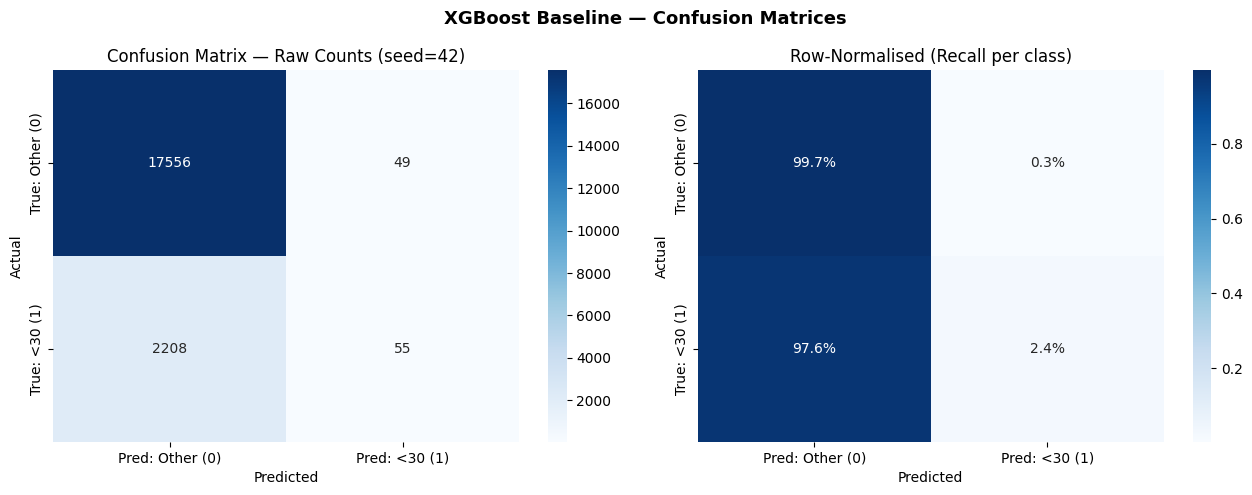

=== Classification Report (seed=42) ===
                    precision    recall  f1-score   support

         Other (0)     0.8883    0.9972    0.9396     17605
Readmitted <30 (1)     0.5288    0.0243    0.0465      2263

          accuracy                         0.8864     19868
         macro avg     0.7086    0.5108    0.4930     19868
      weighted avg     0.8473    0.8864    0.8379     19868



In [16]:
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Pred: Other (0)', 'Pred: <30 (1)'],
    yticklabels=['True: Other (0)', 'True: <30 (1)']
)
axes[0].set_title('Confusion Matrix — Raw Counts (seed=42)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Row-normalised (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt='.1%', cmap='Blues', ax=axes[1],
    xticklabels=['Pred: Other (0)', 'Pred: <30 (1)'],
    yticklabels=['True: Other (0)', 'True: <30 (1)']
)
axes[1].set_title('Row-Normalised (Recall per class)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('XGBoost Baseline — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Classification Report (seed=42) ===')
print(classification_report(
    y_test, y_pred_best,
    target_names=['Other (0)', 'Readmitted <30 (1)'],
    digits=4
))

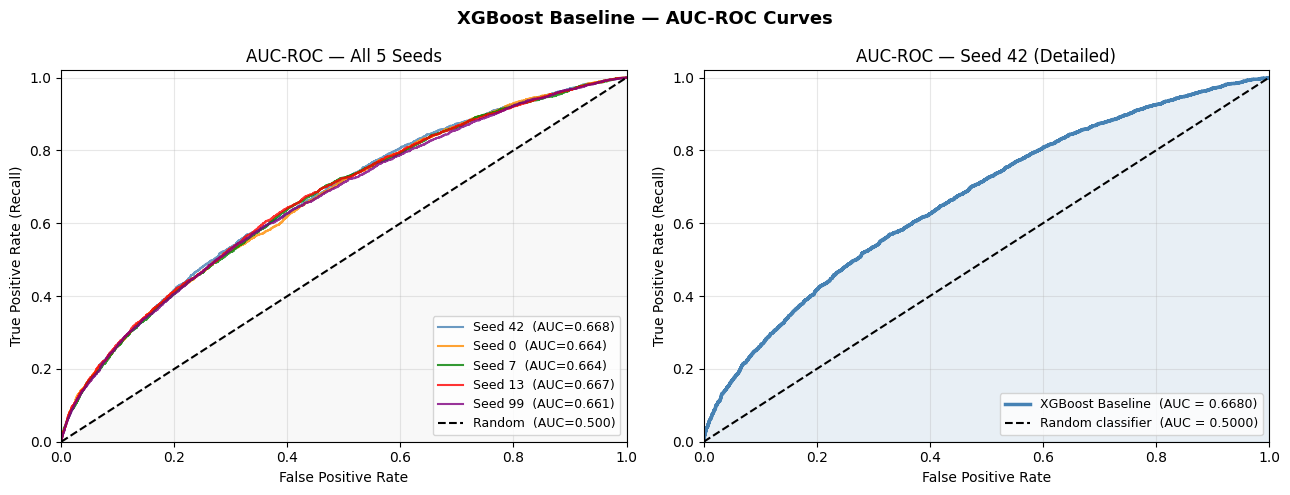

Mean AUC-ROC across 5 seeds: 0.6646 ± 0.0026


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']

# Left: all 5 seeds overlaid
for i, (seed, clf) in enumerate(zip(SEEDS, models)):
    prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=colors[i], alpha=0.8,
                 label=f'Seed {seed}  (AUC={auc_scores[i]:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random  (AUC=0.500)')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('AUC-ROC — All 5 Seeds')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.3)

# Right: seed 42 with shaded area
fpr42, tpr42, _ = roc_curve(y_test, y_prob_best)
axes[1].plot(fpr42, tpr42, color='steelblue', lw=2.5,
             label=f'XGBoost Baseline  (AUC = {auc_scores[0]:.4f})')
axes[1].fill_between(fpr42, tpr42, alpha=0.12, color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random classifier  (AUC = 0.5000)')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('AUC-ROC — Seed 42 (Detailed)')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('XGBoost Baseline — AUC-ROC Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/baseline_auc_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean AUC-ROC across 5 seeds: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}')

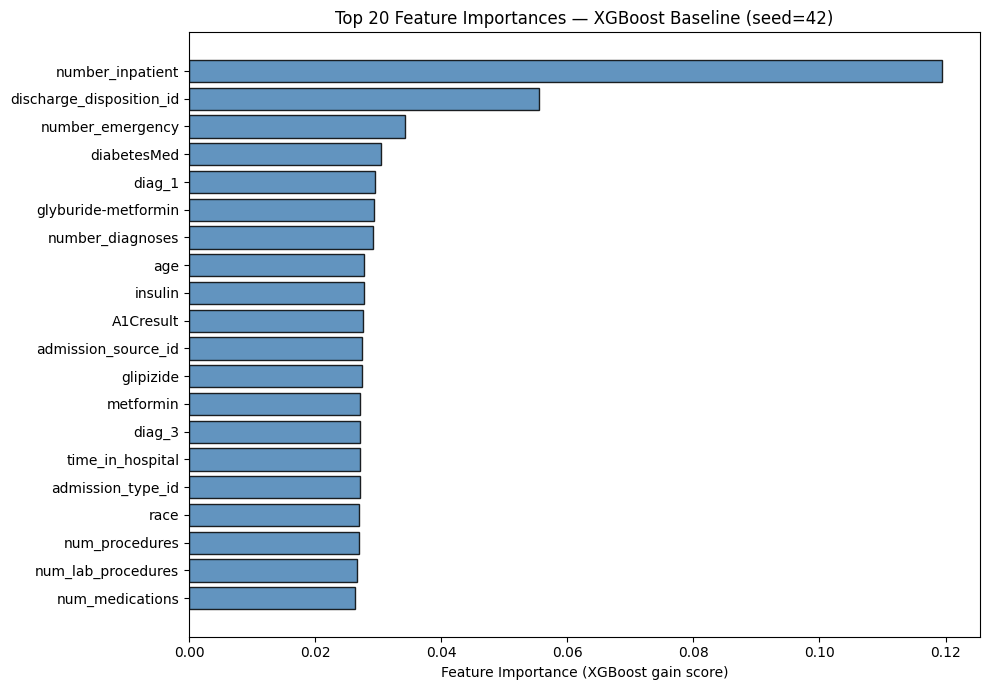

Top 5 features:
  1. number_inpatient                     importance = 0.1195
  2. discharge_disposition_id             importance = 0.0555
  3. number_emergency                     importance = 0.0342
  4. diabetesMed                          importance = 0.0304
  5. diag_1                               importance = 0.0295


In [18]:
feature_names = X_train.columns.tolist()
importances   = best_model.feature_importances_
top_n   = 20
top_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(10, 7))
plt.barh(
    y=[feature_names[i] for i in top_idx[::-1]],
    width=importances[top_idx[::-1]],
    color='steelblue', edgecolor='black', alpha=0.85
)
plt.xlabel('Feature Importance (XGBoost gain score)')
plt.title(f'Top {top_n} Feature Importances — XGBoost Baseline (seed=42)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
for rank, i in enumerate(top_idx[:5], 1):
    print(f'  {rank}. {feature_names[i]:35s}  importance = {importances[i]:.4f}')

In [19]:
baseline_results = {
    'method': 'XGBoost Baseline (No Augmentation)',
    'seeds': SEEDS,
    'f1_per_seed':  [round(v, 4) for v in f1_scores],
    'auc_per_seed': [round(v, 4) for v in auc_scores],
    'mean_f1':  round(float(np.mean(f1_scores)), 4),
    'std_f1':   round(float(np.std(f1_scores)), 4),
    'mean_auc': round(float(np.mean(auc_scores)), 4),
    'std_auc':  round(float(np.std(auc_scores)), 4),
}

with open(f'{METRICS_DIR}/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

joblib.dump(best_model, f'{MODELS_DIR}/xgboost_baseline.pkl')

print('Saved:')
print(f'  {METRICS_DIR}/baseline_results.json')
print(f'  {MODELS_DIR}/xgboost_baseline.pkl')
print(f'  {FIGURES_DIR}/baseline_confusion_matrix.png')
print(f'  {FIGURES_DIR}/baseline_auc_roc.png')
print(f'  {FIGURES_DIR}/baseline_feature_importance.png')

print('\n' + '=' * 57)
print('  STAGE 2 SUMMARY — XGBoost Baseline (No Augmentation)')
print('=' * 57)
print(f'  F1 Score (<30 class) : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}')
print(f'  AUC-ROC              : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}')
print(f'  Train size           : {len(y_train):,}  ({int(y_train.sum()):,} positive  /  {int((y_train==0).sum()):,} negative)')
print(f'  Test  size           : {len(y_test):,}   ({int(y_test.sum()):,} positive  /  {int((y_test==0).sum()):,} negative)')
print('=' * 57)
print()
print('  Next stages — SMOTE, CTGAN, TabDDPM — should improve')
print('  F1(<30) above this baseline number.')

Saved:
  ../results/metrics/baseline_results.json
  ../models/xgboost_baseline.pkl
  ../results/figures/baseline_confusion_matrix.png
  ../results/figures/baseline_auc_roc.png
  ../results/figures/baseline_feature_importance.png

  STAGE 2 SUMMARY — XGBoost Baseline (No Augmentation)
  F1 Score (<30 class) : 0.0459 ± 0.0036
  AUC-ROC              : 0.6646 ± 0.0026
  Train size           : 79,472  (9,051 positive  /  70,421 negative)
  Test  size           : 19,868   (2,263 positive  /  17,605 negative)

  Next stages — SMOTE, CTGAN, TabDDPM — should improve
  F1(<30) above this baseline number.


---
# Stage 3 — Neural Network Architecture (TabDDPM Denoiser)

**Owner:** Jiten Bhalavat

**Goal:** Build the MLP that is the brain of the reverse diffusion process.
Given a noisy patient row, a timestep, and a class label, the network predicts
the Gaussian noise that was added to the numeric columns. Once trained, running
this in reverse generates new synthetic patients.

**Architecture overview:**
- **Input encoding:** numeric features as-is; categoricals through embedding tables
- **Timestep embedding:** sinusoidal encoding -> 2-layer MLP (DDPM standard)
- **Class conditioning:** `nn.Embedding(2, 64)` for the binary readmission label
- **Body:** 4 residual MLP blocks with Adaptive Layer Normalisation (AdaLN)
- **Output:** 9 values - predicted Gaussian noise for each numeric column

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import pickle

# Load diffusion config produced by Anum's forward process
with open('/content/diffusion_config.pkl', 'rb') as f:
    diffusion_cfg = pickle.load(f)

T               = diffusion_cfg['T']
alpha_bars      = diffusion_cfg['alpha_bars']
NUMERIC_INDICES = diffusion_cfg['numeric_indices']
CAT_INDICES     = diffusion_cfg['cat_indices']
CAT_NUM_CLASSES = diffusion_cfg['cat_num_classes']
NUMERIC_COLS    = diffusion_cfg['numeric_columns']
CAT_COLS        = diffusion_cfg['categorical_columns']

NUM_NUMERIC   = len(NUMERIC_INDICES)
NUM_CAT       = len(CAT_INDICES)
CAT_EMB_DIMS  = [max(2, min(16, (K + 1) // 2)) for K in CAT_NUM_CLASSES]
TOTAL_CAT_EMB = sum(CAT_EMB_DIMS)
TOTAL_INPUT   = NUM_NUMERIC + TOTAL_CAT_EMB

print(f'T = {T}')
print(f'Numeric features : {NUM_NUMERIC}   indices: {NUMERIC_INDICES}')
print(f'Categorical feats: {NUM_CAT}')
print(f'Cat emb total dim: {TOTAL_CAT_EMB}  per-col dims (first 8): {CAT_EMB_DIMS[:8]}')
print(f'Total MLP input  : {NUM_NUMERIC} + {TOTAL_CAT_EMB} = {TOTAL_INPUT}')
print(f'MLP output       : {NUM_NUMERIC}  (noise for each numeric column)')

T = 1000
Numeric features : 9   indices: [6, 7, 8, 9, 10, 11, 12, 16, 2]
Categorical feats: 33
Cat emb total dim: 103  per-col dims (first 8): [3, 2, 5, 15, 13, 5, 5, 5]
Total MLP input  : 9 + 103 = 112
MLP output       : 9  (noise for each numeric column)


---
## 16. Sinusoidal Timestep Embedding

The network needs to know *when* in the diffusion process it is - early
(small t, little noise) vs late (large t, mostly noise). We use sinusoidal
positional encoding from Ho et al. (DDPM 2020).

For embedding dimension d:
- Even dims: `sin(t / 10000^(d/D))`
- Odd dims: `cos(t / 10000^(d/D))`

In [22]:
class SinusoidalTimestepEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000)
            * torch.arange(half, dtype=torch.float32, device=t.device)
            / (half - 1)
        )
        args = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


emb_fn = SinusoidalTimestepEmbedding(dim=128)
t_test = torch.tensor([0, 1, 500, 999])
emb_out = emb_fn(t_test)

print(f'Output shape : {emb_out.shape}   (expect torch.Size([4, 128]))')
print(f'Output dtype : {emb_out.dtype}')
print('Each timestep gets a unique vector (first 6 dims):')
for i, ts in enumerate(t_test.tolist()):
    print(f'  t={ts:4d}: {emb_out[i, :6].detach().numpy().round(3)}')

Output shape : torch.Size([4, 128])   (expect torch.Size([4, 128]))
Output dtype : torch.float32
Each timestep gets a unique vector (first 6 dims):
  t=   0: [0. 0. 0. 0. 0. 0.]
  t=   1: [0.841 0.76  0.679 0.601 0.529 0.463]
  t= 500: [-0.468 -1.     0.574  0.896  0.835  0.926]
  t= 999: [-0.026  0.727 -0.922 -0.272 -0.571 -0.288]


---
## 17. Residual Block with AdaLN Conditioning

Each block applies a 2-layer FFN with a skip connection. Conditioning is
injected via Adaptive Layer Normalisation (AdaLN).

Near-identity init: `linear2` is zero-init so the block starts as a pure
skip connection (`output = x`).

In [23]:
class ResidualBlock(nn.Module):
    def __init__(self, dim: int, cond_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.linear1 = nn.Linear(dim, dim * 2)
        self.act = nn.SiLU()
        self.linear2 = nn.Linear(dim * 2, dim)
        self.dropout = nn.Dropout(dropout)
        self.cond_proj = nn.Linear(cond_dim, dim * 2)
        nn.init.zeros_(self.linear2.weight)
        nn.init.zeros_(self.linear2.bias)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        h = self.norm(x)
        scale, shift = self.cond_proj(cond).chunk(2, dim=-1)
        h = h * (1.0 + scale) + shift
        h = self.act(self.linear1(h))
        h = self.dropout(h)
        h = self.linear2(h)
        return x + h


torch.manual_seed(0)
block = ResidualBlock(dim=256, cond_dim=256)
block.train()
x_dummy = torch.randn(8, 256)
cond_dummy = torch.randn(8, 256)
out = block(x_dummy, cond_dummy)

print(f'Output shape : {tuple(out.shape)}   (expect (8, 256))')
print(f'Has NaN      : {torch.isnan(out).any().item()}   (expect False)')

diff = (out - x_dummy).abs().mean().item()
print(f'Near-identity: mean |output - input| = {diff:.8f}   (expect 0.0)')

out.mean().backward()
grad_norm = block.linear2.weight.grad.abs().mean().item()
print(f'linear2 grad : {grad_norm:.6f}   (expect > 0)')
print('Backward     : PASS')

Output shape : (8, 256)   (expect (8, 256))
Has NaN      : False   (expect False)
Near-identity: mean |output - input| = 0.00000000   (expect 0.0)
linear2 grad : 0.000586   (expect > 0)
Backward     : PASS


---
## 18. TabDDPM Denoiser - Full Architecture

`x_noisy` (batch, 42) is split into numeric and categorical paths, categorical
features are embedded, timestep and class embeddings are combined as conditioning,
then 4 AdaLN residual blocks predict noise for numeric columns only.

In [24]:
class TabDDPMDenoiser(nn.Module):
    def __init__(
        self,
        num_numeric: int,
        cat_cardinalities: list,
        numeric_indices: list,
        cat_indices: list,
        hidden_dim: int = 256,
        depth: int = 4,
        time_emb_dim: int = 128,
        class_emb_dim: int = 64,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.numeric_indices = numeric_indices
        self.cat_indices = cat_indices
        self.num_numeric = num_numeric

        cat_emb_dims = [max(2, min(16, (K + 1) // 2)) for K in cat_cardinalities]
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(K, d) for K, d in zip(cat_cardinalities, cat_emb_dims)
        ])
        total_cat_emb = sum(cat_emb_dims)

        self.input_proj = nn.Sequential(
            nn.Linear(num_numeric + total_cat_emb, hidden_dim),
            nn.SiLU(),
        )

        self.time_sin = SinusoidalTimestepEmbedding(time_emb_dim)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.class_emb = nn.Embedding(2, class_emb_dim)
        self.class_proj = nn.Sequential(
            nn.Linear(class_emb_dim, hidden_dim),
            nn.SiLU(),
        )

        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, hidden_dim, dropout)
            for _ in range(depth)
        ])

        self.output_head = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, num_numeric),
        )

    def forward(self, x_noisy: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        x_num = x_noisy[:, self.numeric_indices].float()
        x_cat = x_noisy[:, self.cat_indices].long()

        cat_emb = torch.cat(
            [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)], dim=-1
        )
        h = self.input_proj(torch.cat([x_num, cat_emb], dim=-1))

        t_emb = self.time_mlp(self.time_sin(t))
        c_emb = self.class_proj(self.class_emb(y.long()))
        cond = t_emb + c_emb

        for block in self.blocks:
            h = block(h, cond)

        return self.output_head(h)


torch.manual_seed(42)
model = TabDDPMDenoiser(
    num_numeric=NUM_NUMERIC,
    cat_cardinalities=CAT_NUM_CLASSES,
    numeric_indices=NUMERIC_INDICES,
    cat_indices=CAT_INDICES,
)
model.train()

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')
print()

BATCH = 64
x_dummy = torch.zeros(BATCH, 42)
for j, (ci, K) in enumerate(zip(CAT_INDICES, CAT_NUM_CLASSES)):
    x_dummy[:, ci] = torch.randint(0, K, (BATCH,)).float()
t_dummy = torch.randint(0, 1000, (BATCH,))

noise_pred = model(x_dummy, t_dummy, torch.zeros(BATCH, dtype=torch.long))
print(f'1. Output shape : {tuple(noise_pred.shape)}   (expect ({BATCH}, {NUM_NUMERIC}))')
print(f'   Has NaN      : {torch.isnan(noise_pred).any().item()}   (expect False)')

noise_pred.mean().backward()
grad_norms = [b.linear2.weight.grad.abs().mean().item() for b in model.blocks]
print(f'2. Backward     : PASS')
print(f'   linear2 grads: {[round(g,5) for g in grad_norms]}  (all > 0)')

optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
for _ in range(3):
    model.zero_grad()
    p = model(x_dummy, t_dummy, torch.zeros(BATCH, dtype=torch.long))
    F.mse_loss(p, torch.randn_like(p)).backward()
    optimizer.step()

model.eval()
with torch.no_grad():
    out_y0 = model(x_dummy[:8], t_dummy[:8], torch.zeros(8, dtype=torch.long))
    out_y1 = model(x_dummy[:8], t_dummy[:8], torch.ones(8, dtype=torch.long))
diff = (out_y0 - out_y1).abs().mean().item()
print(f'3. Class cond   : mean |y0-y1| = {diff:.6f}   --> {"PASS" if diff > 0 else "FAIL"}')
print()
print('All checks passed. Model ready for Rohith training loop.')

Total parameters: 1,728,503

1. Output shape : (64, 9)   (expect (64, 9))
   Has NaN      : False   (expect False)
2. Backward     : PASS
   linear2 grads: [0.00481, 0.0043, 0.00465, 0.00457]  (all > 0)
3. Class cond   : mean |y0-y1| = 0.020331   --> PASS

All checks passed. Model ready for Rohith training loop.
